## FEM Pipeline

```text
Physical Mesh
     │
     ▼
Reference Triangle (r,s)
     │
     ▼
Basis Evaluation
     │
     ▼
Local Element Operators
     │
     ▼
Global Assembly
     │
     ▼
Global Projection / Solve
```

### Coordinate Ownership

| Layer | Coordinates | Responsibility |
|-------|-------------|----------------|
| Mesh | `(x,y)` | Physical geometry and topology |
| Geometry | `(x,y) ⇄ (r,s)` | Element mappings |
| Quadrature | `(r,s)` | Integration points and weights |
| Basis | `(r,s)` | Evaluate basis and gradients |
| Assembly | `(r,s)` + DOFs | Form local/global operators |
| Solver | Global DOFs | Solve the linear system |

> **Design Principle:** The collapsed coordinates `(ξ,η)` are an implementation detail of the Dubiner basis and quadrature generation. They should never appear in the public FEM, geometry, or assembly interfaces.

In [ ]:
from localtfem.geometry.structured_mesh import structured_mesh

p = 1
level = -1

mesh = structured_mesh(level)

mesh.plot_topology(
    node_ids=True,
    local_labels=True,
    local_edge_arrows=True,
    edge_arrows=True
)

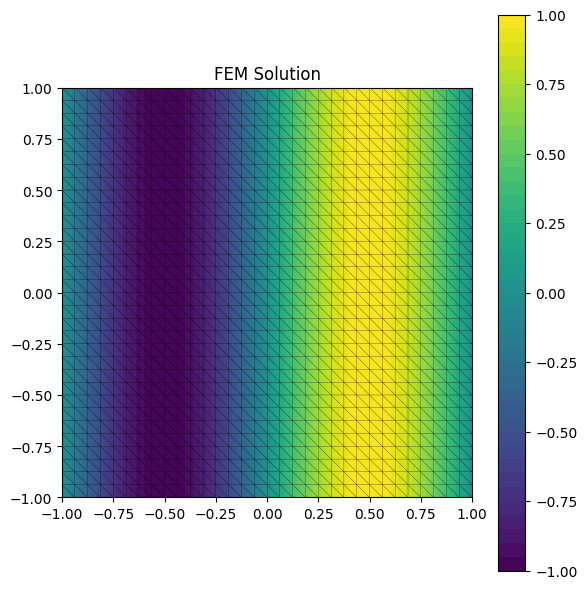

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from localtfem.geometry.structured_mesh import structured_mesh
from localtfem.modified_dubiner.dubiner_sym import symbolic_mass_matrix 
from localtfem.fem.assembly import assemble_global_matrix, assemble_global_vector
from localtfem.fem.dof_map import DOFMap
from localtfem.fem.rhs import eval_rhs
from localtfem.fem.visualization import plot_solution

p = 3
level = 4

def u_exact(x, y):
    return 1.0*np.sin(1.0*np.pi * x) 

mesh = structured_mesh(level)
# mesh.plot_topology(
#     node_ids=True,
#     local_labels=True,
#     local_edge_arrows=True,
#     edge_arrows=True
# )

dofmap = DOFMap(
    p=p,
    Nodes=mesh.nodes,
    Edges=mesh.edges,
    Conn=mesh.elements
)

M_ref = symbolic_mass_matrix(p) #.evalf()
# print( f"Reference Mass:" )
# display( M_ref )

M_global = assemble_global_matrix(
    M_ref,
    mesh.areas,
    dofmap
)

np.set_printoptions(precision=3, suppress=True)
# print(M_global.toarray())

# ============================================================
# RHS ASSEMBLY (THIS IS THE NEW PART)
# ============================================================

num_elems = mesh.elements.shape[0]
loc_dim = M_ref.shape[0]

# element-wise RHS vectors
b_local = np.zeros((num_elems, loc_dim))

for e in range(num_elems):
    verts = mesh.vertices(e)
    b_local[e] = eval_rhs(u_exact, verts, p)

# global RHS vector
b_global = assemble_global_vector(
    b_local,
    dofmap
)

# print("\nGlobal RHS vector:")
# print(b_global)

# ============================================================
# SOLVE PROJECTION
# ============================================================
u_h = np.linalg.solve(M_global.toarray(), b_global)

# print("\nSolution coefficients:")
# print(u_h)

plot_solution(
    mesh=mesh,
    dofmap=dofmap,
    u=u_h,
    p=p,
    resolution=10, 
    # zlim=[4,7.0]
)

# plot_solution(mesh, dofmap, u_h, p, element=0)

# print("M shape:", M_global.shape)
# print("Symmetry error:", np.linalg.norm(M_global - M_global.T))
# print("Eigenvalues:", np.linalg.eigvalsh(M_global))